In [1]:
# imports
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import colormaps
import seaborn as sns

In [2]:
df = pd.read_csv('pairwise_pvalues.csv')

In [3]:
df.head()

,contrast,estimate,SE,df,z.ratio,p.value
0,zscore - clahe,0.092021,0.048932,inf,1.880599,4.932640e-01
1,zscore - clip_and_rescale,0.476780,0.048932,inf,9.743780,7.960299e-14
2,zscore - gmm,0.513045,0.048932,inf,10.484906,6.250556e-14
3,zscore - hist_eq,0.645225,0.048932,inf,13.186225,0.000000e+00
4,zscore - nyul,-0.143178,0.048932,inf,-2.926075,5.329030e-02


In [4]:
# Split 'contrast' into method pairs
df[['Method1', 'Method2']] = df['contrast'].str.split(' - ', expand=True)

In [5]:
df.head()

,contrast,estimate,SE,df,z.ratio,p.value,Method1,Method2
0,zscore - clahe,0.092021,0.048932,inf,1.880599,4.932640e-01,zscore,clahe
1,zscore - clip_and_rescale,0.476780,0.048932,inf,9.743780,7.960299e-14,zscore,clip_and_rescale
2,zscore - gmm,0.513045,0.048932,inf,10.484906,6.250556e-14,zscore,gmm
3,zscore - hist_eq,0.645225,0.048932,inf,13.186225,0.000000e+00,zscore,hist_eq
4,zscore - nyul,-0.143178,0.048932,inf,-2.926075,5.329030e-02,zscore,nyul


In [6]:
# Pivot to wide format (matrix)
heatmap_data = df.pivot(index='Method1', columns='Method2', values='p.value')

In [7]:
heatmap_data

Method2,clahe,clip_and_rescale,gmm,hist_eq,nyul,rescale
Method1,,,,,,
clahe,NaN,1.814104e-13,6.217249e-14,9.325873e-15,0.000032,6.883383e-14
clip_and_rescale,NaN,NaN,9.900017e-01,1.034716e-02,0.000000,9.969269e-01
gmm,NaN,NaN,NaN,9.783625e-02,0.000000,9.999992e-01
hist_eq,NaN,NaN,NaN,NaN,0.000000,6.673048e-02
nyul,NaN,NaN,NaN,NaN,NaN,0.000000e+00
zscore,0.493264,7.960299e-14,6.250556e-14,0.000000e+00,0.053290,6.727952e-14


In [8]:
method_order = ["nyul", "zscore", "clahe", "clip_and_rescale", "rescale", "gmm", "hist_eq"]

# Reorder the DataFrame based on method_order
heatmap_data = heatmap_data.reindex(index=method_order, columns=method_order)

# rename the index and columns

column_names = [
    "Nyúl",
    "Z-score",
    "CLAHE",
    "R. Min-max",
    "Min-max",
    "GMM",
    "HE"
]

heatmap_data.columns = column_names
heatmap_data.index = column_names

heatmap_data

,Nyúl,Z-score,CLAHE,R. Min-max,Min-max,GMM,HE
Nyúl,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN
Z-score,0.053290,NaN,0.493264,7.960299e-14,6.727952e-14,6.250556e-14,0.000000e+00
CLAHE,0.000032,NaN,NaN,1.814104e-13,6.883383e-14,6.217249e-14,9.325873e-15
R. Min-max,0.000000,NaN,NaN,NaN,9.969269e-01,9.900017e-01,1.034716e-02
Min-max,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GMM,0.000000,NaN,NaN,NaN,9.999992e-01,NaN,9.783625e-02
HE,0.000000,NaN,NaN,NaN,6.673048e-02,NaN,NaN


In [9]:
# mirror the values across the diagonal
for i in heatmap_data.index:
    for j in heatmap_data.columns:
        if pd.isna(heatmap_data.loc[i, j]) and not pd.isna(heatmap_data.loc[j, i]):
            heatmap_data.loc[i, j] = heatmap_data.loc[j, i]

In [10]:
heatmap_data

,Nyúl,Z-score,CLAHE,R. Min-max,Min-max,GMM,HE
Nyúl,NaN,5.329030e-02,3.160471e-05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Z-score,0.053290,NaN,4.932640e-01,7.960299e-14,6.727952e-14,6.250556e-14,0.000000e+00
CLAHE,0.000032,4.932640e-01,NaN,1.814104e-13,6.883383e-14,6.217249e-14,9.325873e-15
R. Min-max,0.000000,7.960299e-14,1.814104e-13,NaN,9.969269e-01,9.900017e-01,1.034716e-02
Min-max,0.000000,6.727952e-14,6.883383e-14,9.969269e-01,NaN,9.999992e-01,6.673048e-02
GMM,0.000000,6.250556e-14,6.217249e-14,9.900017e-01,9.999992e-01,NaN,9.783625e-02
HE,0.000000,0.000000e+00,9.325873e-15,1.034716e-02,6.673048e-02,9.783625e-02,NaN


In [11]:
# turn dataframe to triangular matrix
mask = np.tril(np.ones_like(heatmap_data, dtype=bool))
heatmap_data_masked = heatmap_data.where(~mask)

heatmap_data_masked

,Nyúl,Z-score,CLAHE,R. Min-max,Min-max,GMM,HE
Nyúl,NaN,0.05329,0.000032,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Z-score,NaN,NaN,0.493264,7.960299e-14,6.727952e-14,6.250556e-14,0.000000e+00
CLAHE,NaN,NaN,NaN,1.814104e-13,6.883383e-14,6.217249e-14,9.325873e-15
R. Min-max,NaN,NaN,NaN,NaN,9.969269e-01,9.900017e-01,1.034716e-02
Min-max,NaN,NaN,NaN,NaN,NaN,9.999992e-01,6.673048e-02
GMM,NaN,NaN,NaN,NaN,NaN,NaN,9.783625e-02
HE,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
def format_p_value(val):
    return "<0.001" if val < 0.001 else f"{val:.3f}"

# make heatmap of p-values
cmap = colormaps["Blues_r"]

bad = cmap(0)
low_sig = cmap(0.33)
high_sig= cmap(0.66)
max_sig = cmap(0.99)

# Define custom color mapping
colours = [max_sig, high_sig, low_sig, bad]
# normal significance levels
sig_levels = [0, 0.001, 0.01, 0.05]
bounds = np.append(np.array(sig_levels), [1]) # Boundaries: 0 → 0.001 → 0.01 → 0.05 → 1
ticks = sig_levels + [1]

# Create a colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colours, N=256)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

(6, 6)
(7, 7)


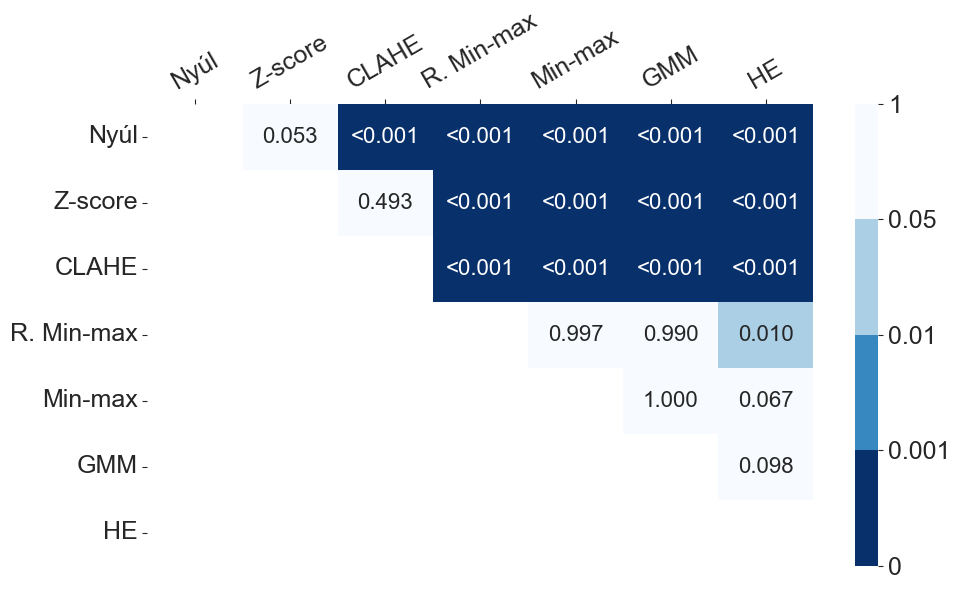

In [14]:
# heatmap
# Trim empty first column and bottom row
heatmap_data_masked_short = heatmap_data_masked.iloc[:-1, 1:]

# print shape of trimmed dataframe
print(heatmap_data_masked_short.shape)

annot_ext_pvals = np.vectorize(format_p_value)(heatmap_data_masked.values)

print(annot_ext_pvals.shape)

# format seaborn style
sns.set_style("ticks")

# set cmap as a gradient from white to blue 
#inverted cmap
cmap = colormaps["Blues_r"]

# make heatmap of p-values
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data_masked, annot=annot_ext_pvals, cmap=cmap, norm=norm, fmt="", annot_kws={"size": 16})

# Set custom colorbar ticks and labels
cbar = ax.collections[0].colorbar
cbar.set_ticks(bounds)  # Explicitly include 0.0024
tick_labels = [f"{t}" if t != int(t) else f"{t}" for t in ticks]
cbar.set_ticklabels(tick_labels)  # Force 0.0024 as a label
cbar.ax.tick_params(labelsize=18)

# move x ticks to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Adjust tick labels
plt.xticks(fontsize=18, rotation=30)
plt.yticks(fontsize=18, rotation=0)
plt.tight_layout()
plt.savefig('p_values_LMM_external_dice_scores_Blues.pdf', format='pdf', dpi=800, bbox_inches='tight')
plt.show()